# Week 17: Attention as a learned kernel on a wake

Which properties follow from the attention algebra, and which require physical validation?

**Prerequisites:** Weeks 7.3 and 15 introduced applications. Here we open the mechanism and audit it.

Allow 120 minutes plus the written analysis. Instructor solution edition.

In [1]:
from pathlib import Path
import sys, tempfile, json
ROOT=next((p for p in [Path.cwd(),*Path.cwd().parents] if (p/'flowmllab/transformer_course.py').exists()),None)
if ROOT is None:
    raise RuntimeError('Extract the supplied course bundle and start Jupyter in its root; see docs/TRANSFORMER_COURSE.md for Colab upload setup.')
sys.path.insert(0,str(ROOT))
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from IPython.display import display
from flowmllab import transformer_course as lab
lab.seed_all(17)
cases,input_manifest=lab.load_data(ROOT)
EVIDENCE=ROOT/'results/transformer_course_v3'
# Any optional experiment must write into this disposable workspace.
workspace=tempfile.TemporaryDirectory(prefix='flowmllab-student-')
RUN_OUTPUT=Path(workspace.name)
task_status={}
print('Loaded checksummed simulated wake fields. No retained files will be rewritten.')

task_status={i:None for i in range(1,5)}


Loaded checksummed simulated wake fields. No retained files will be rewritten.


In [2]:
RUN_EXERCISES=True

## Build Q, K and V from actual CFD sensors

Coordinates are geometric features, not a sequence order. Use the first retained Re110 snapshot only as a worked example; these random weights are not a learned physical law.

X, Q, attention, output: torch.Size([3, 16, 3]) torch.Size([3, 16, 8]) torch.Size([3, 16, 16]) torch.Size([3, 16, 8])


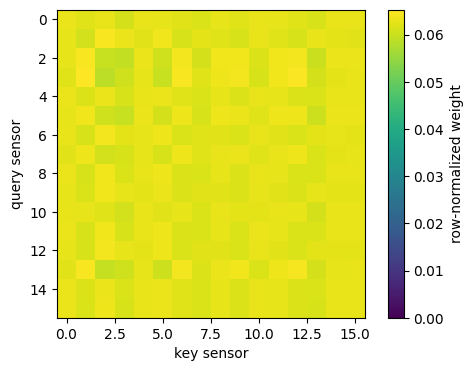

In [3]:
rep=lab.Representation.fit(cases[90]['v'][:160],8)
ids=lab.qr_sensors(rep,16)
tokens=lab.sensor_tokens(cases[110]['v'][100:103],ids,cases[90],0.,1.)
X=torch.tensor(tokens,dtype=torch.float32)
Wq,Wk,Wv=[torch.randn(3,8)/np.sqrt(3) for _ in range(3)]
Q,K,V=X@Wq,X@Wk,X@Wv
A,weights=lab.attention(Q,K,V)
print('X, Q, attention, output:',X.shape,Q.shape,weights.shape,A.shape)
assert torch.allclose(weights.sum(-1),torch.ones(3,16))
plt.figure(figsize=(6,4));plt.imshow(weights[0].numpy(),vmin=0,cmap='viridis');plt.colorbar(label='row-normalized weight');plt.xlabel('key sensor');plt.ylabel('query sensor');plt.show()

## Separate a kernel picture from a trained interpretation

A spatial-distance kernel supplies a geometry-only comparator. Neither picture is evidence of causal influence. Change a sensor value and recompute both kernels.

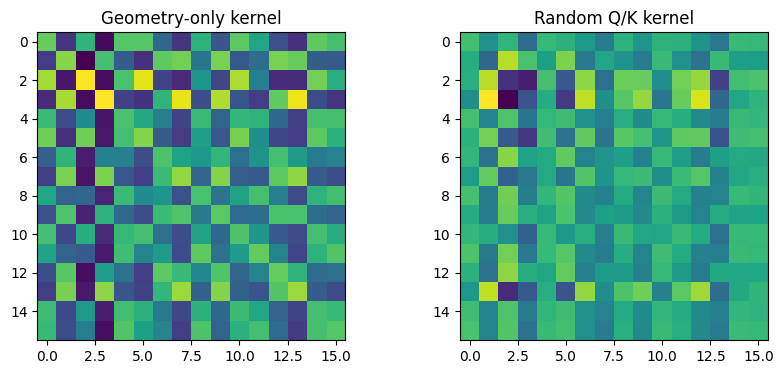

In [4]:
xy=tokens[0,:,1:]
distance=((xy[:,None]-xy[None,:])**2).sum(-1)
geometry=np.exp(-distance/.1);geometry/=geometry.sum(1,keepdims=True)
order=torch.randperm(16)
permuted,_=lab.attention(Q[:,order],K[:,order],V[:,order])
torch.testing.assert_close(permuted,A[:,order])
fig,axes=plt.subplots(1,2,figsize=(10,4))
axes[0].imshow(geometry);axes[0].set_title('Geometry-only kernel')
axes[1].imshow(weights[0].numpy());axes[1].set_title('Random Q/K kernel')
plt.show()

## Task 1: Scaled attention

Implement row-stable scaled dot-product attention without calling lab.attention. Explain the square-root scaling.

Interface contract: Inputs are floating Torch tensors q,k:[N,d], v:[N,d_v] with matching N. Return a [N,d_v] tensor; normalize over keys.

In [5]:
def student_attention(q,k,v):
    score=q@k.transpose(-2,-1)/np.sqrt(q.shape[-1])
    return score.softmax(-1)@v

In [6]:
if RUN_EXERCISES:
    try:
        g=torch.Generator().manual_seed(1701)
        for b,n,d in [(2,5,3),(1,9,6)]:
            q,k,v=[torch.randn(b,n,d,generator=g) for _ in range(3)]
            expected=(q@k.transpose(-2,-1)/np.sqrt(d)).softmax(-1)@v
            torch.testing.assert_close(student_attention(q,k,v),expected)
            torch.testing.assert_close(student_attention(q,k,2*v),2*expected)
        task_status[1]=True
    except NotImplementedError:
        task_status[1]=None
    except Exception as exc:
        task_status[1]=False
        print("Task 1 check failed:",type(exc).__name__,str(exc))
else:
    task_status[1]=None
print("Task 1:","PASS" if task_status[1] is True else "NOT SUBMITTED" if task_status[1] is None else "FAILED")

Task 1: PASS


## Task 2: Permutation experiment

Write a function returning the largest equivariance error after consistently permuting all sensor tokens.

Interface contract: Inputs q,k,v have the Task 1 shapes. order is a length-N Torch permutation. attention_fn is an explicit callable returning the attended tensor, not a weights/output tuple. Return a Python float: maximum absolute equivariance discrepancy. Do not consult a global attention function.

In [7]:
def permutation_error(q,k,v,order,attention_fn):
    before=attention_fn(q,k,v)
    after=attention_fn(q[order],k[order],v[order])
    return float((after-before[order]).abs().max())

In [8]:
if RUN_EXERCISES:
    try:
        for n,d in ((5,3),(9,2)):
            q=torch.randn(n,d);k=torch.randn(n,d);v=torch.randn(n,4);order=torch.randperm(n)
            assert permutation_error(q,k,v,order,student_attention)<1e-5
        def order_biased_attention(q,k,v):
            return torch.arange(q.shape[0],dtype=q.dtype)[:,None].expand(q.shape[0],v.shape[-1])
        q=torch.randn(5,3);k=torch.randn(5,3);v=torch.randn(5,2);order=torch.arange(4,-1,-1)
        assert permutation_error(q,k,v,order,order_biased_attention)>1
        task_status[2]=True
    except NotImplementedError:
        task_status[2]=None
    except Exception as exc:
        task_status[2]=False
        print("Task 2 check failed:",type(exc).__name__,str(exc))
else:
    task_status[2]=None
print("Task 2:","PASS" if task_status[2] is True else "NOT SUBMITTED" if task_status[2] is None else "FAILED")

Task 2: PASS


## Task 3: Temperature limit

Implement temperature-scaled weights; verify that large temperature moves them toward uniform weights.

Interface contract: Return a [N,N] Torch tensor for q,k:[N,d]. Divide scaled scores by the finite temperature; nonpositive temperature must raise ValueError.

In [9]:
def temperature_weights(q,k,temperature):
    if temperature<=0: raise ValueError("temperature must be positive")
    return (q@k.transpose(-2,-1)/np.sqrt(q.shape[-1])/temperature).softmax(-1)

In [10]:
if RUN_EXERCISES:
    try:
        for temperature in (.3,2.5):
            expected=(Q@K.transpose(-2,-1)/np.sqrt(Q.shape[-1])/temperature).softmax(-1)
            torch.testing.assert_close(temperature_weights(Q,K,temperature),expected)
        try:
            temperature_weights(Q,K,0)
            raise AssertionError('zero temperature was accepted')
        except ValueError:
            pass
        task_status[3]=True
    except NotImplementedError:
        task_status[3]=None
    except Exception as exc:
        task_status[3]=False
        print("Task 3 check failed:",type(exc).__name__,str(exc))
else:
    task_status[3]=None
print("Task 3:","PASS" if task_status[3] is True else "NOT SUBMITTED" if task_status[3] is None else "FAILED")

Task 3: PASS


## Task 4: Build an attention investigation

Implement attention over several temperatures and optional key masks. Return weights, output and mean entropy for each temperature. Reject a mask with an empty row. Then vary the temperature and remove half the keys; plot entropy and output change, explaining why constant values hide changes in attention.

Interface contract: Inputs q:[Nq,d], k:[Nk,d], v:[Nk,d_v] are 2-D floating Torch tensors. temperatures is a nonempty sequence of positive scalars. mask is None or a Boolean tensor broadcastable to [Nq,Nk]: True ALLOWS a key (the opposite of torch MultiheadAttention blocking-mask semantics). Invalid tensor dimensions, mismatched widths/counts, nonpositive temperature or a query with no allowed key must raise ValueError. Return a list in temperature order of dictionaries with keys temperature (float), weights ([Nq,Nk] tensor), output ([Nq,d_v] tensor), entropy (float, mean over queries of natural-log entropy).

In [11]:
def attention_investigation(q,k,v,temperatures,mask=None):
    if q.ndim!=2 or k.ndim!=2 or v.ndim!=2:
        raise ValueError('expected two-dimensional tensors')
    if q.shape[-1]!=k.shape[-1] or k.shape[-2]!=v.shape[-2]:
        raise ValueError('incompatible feature or token dimensions')
    scores=q@k.transpose(-2,-1)/np.sqrt(q.shape[-1])
    if mask is not None:
        mask=torch.broadcast_to(mask.bool(),scores.shape)
        if not bool(mask.any(-1).all()):
            raise ValueError('every query must retain a key')
    if len(temperatures)==0:raise ValueError("no temperatures")
    result=[]
    for temperature in temperatures:
        if temperature<=0:
            raise ValueError('temperature must be positive')
        scaled=scores/temperature
        if mask is not None:
            scaled=scaled.masked_fill(~mask,float('-inf'))
        weights=scaled.softmax(-1)
        entropy=-(weights*weights.clamp_min(1e-30).log()).sum(-1).mean()
        result.append({'temperature':temperature,'weights':weights,'output':weights@v,'entropy':float(entropy)})
    return result

In [12]:
if RUN_EXERCISES:
    try:
        g=torch.Generator().manual_seed(1704)
        q,k,v=[torch.randn(5,3,generator=g) for _ in range(3)]
        mask=torch.ones(5,5,dtype=torch.bool);mask[:,-2:]=False
        for use_mask in (None,mask):
            result=attention_investigation(q,k,v,[.5,3.],use_mask)
            assert len(result)==2
            for r in result:
                scores=q@k.transpose(-2,-1)/np.sqrt(3)/r['temperature']
                if use_mask is not None:scores=scores.masked_fill(~use_mask,float('-inf'))
                expected=scores.softmax(-1)
                torch.testing.assert_close(r['weights'],expected)
                torch.testing.assert_close(r['output'],expected@v)
                assert np.isclose(r['entropy'],float(-(expected*expected.clamp_min(1e-30).log()).sum(-1).mean()))
            assert result[0]['entropy']<result[1]['entropy']
        try:
            attention_investigation(q,k,v,[1.],torch.zeros(5,5,dtype=torch.bool))
            raise AssertionError('empty mask accepted')
        except ValueError:pass
        for temp in (0.,-1.):
            try:
                attention_investigation(q,k,v,[temp])
                raise AssertionError("nonpositive temperature accepted")
            except ValueError:pass
        task_status[4]=True
    except NotImplementedError:
        task_status[4]=None
    except Exception as exc:
        task_status[4]=False
        print("Task 4 check failed:",type(exc).__name__,str(exc))
else:
    task_status[4]=None
print("Task 4:","PASS" if task_status[4] is True else "NOT SUBMITTED" if task_status[4] is None else "FAILED")

Task 4: PASS


## Interpretation and submission

Submit the four completed functions, the requested plots/tables, and a 300-word claim ledger. Distinguish observations, fitted quantities, independent evaluation and unsupported extrapolation. Retain failed seeds. Use the lecture source for the rubric and assumptions.

In [13]:
print("Coding tasks passed:",sum(v is True for v in task_status.values()),"/",len(task_status))
assert all(v is True for v in task_status.values())
workspace.cleanup()

Coding tasks passed: 4 / 4
